In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import hvplot.xarray
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from scipy.optimize import curve_fit

### Checking Old Calibration

In [2]:
calib_dir = 'C:/Users/RalphGroup/Documents/group_code/daedalus_control/calibrations/'
base_volt_coeff= np.loadtxt(calib_dir + 'daedalus_volt_center_calib.csv', delimiter=',')
base_volt_calib = np.poly1d(base_volt_coeff)

In [3]:
base_volt_coeff

array([ 2.67998879e+05,  5.76602968e+03, -7.54013318e+04, -1.23571710e+03,
        7.78007285e+03,  8.86964487e+01, -1.45283681e+02, -9.10596441e-01,
        2.14689995e+01,  5.12205619e-02])

In [6]:
measured = pd.read_csv('test_daedalus_voltCenter_calib_2025-06-26_2.csv', comment = '#')

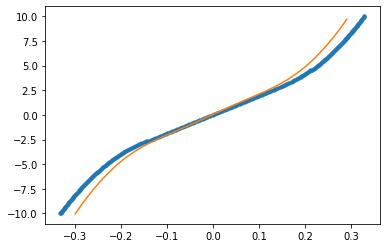

In [9]:
fields = np.arange(-0.3, 0.3, 0.01)
plt.plot(measured['Xfield'], measured['V'],'.')
plt.plot(fields, base_volt_calib(fields))

### Fit new Calibration

[ 9.87556039e+04  2.11599351e+03 -3.47009464e+04 -5.81344659e+02
  4.46993359e+03  5.33397000e+01 -1.02550748e+02 -7.37243769e-01
  1.92502361e+01  4.82854717e-02]


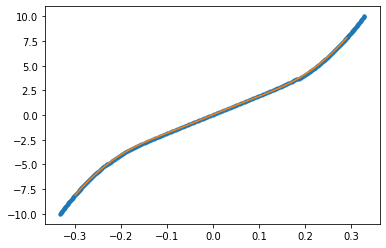

In [ ]:
base_volt_coeff_new = np.polyfit(measured['Xfield'], measured['V'], 9)
base_volt_calib_new = np.poly1d(base_volt_coeff_new)
print(base_volt_coeff_new)
plt.plot(measured['Xfield'], measured['V'], '.')
fields = np.arange(-0.3, 0.3, 0.01)
plt.plot(fields, base_volt_calib_new(fields))
#save to volt_center (base_volt)

### Compare with old calibration

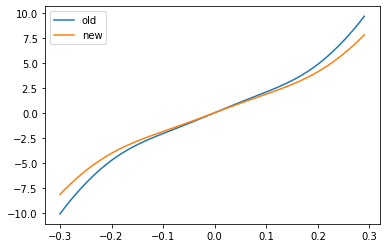

In [11]:
plt.plot(fields, base_volt_calib(fields), label = 'old')
plt.plot(fields, base_volt_calib_new(fields), label = 'new')
plt.legend()

### Check with 90deg

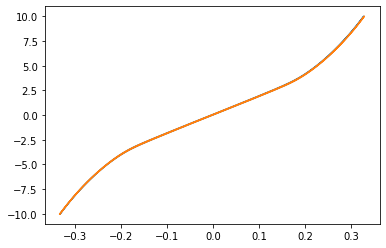

In [12]:
measured90deg = pd.read_csv('test_daedalus_voltCenter_calib_2025-06-26_3.csv', comment = '#')
plt.plot(measured['Xfield'], measured['V'])
plt.plot(measured90deg['Yfield'], measured90deg['V'])